# Visualize mSWE-GNN results on Ahr river (additionalsrc cutpolygon)
Runs inference with  against SFINCS ground truth .

In [1]:
import sys, os

# Resolve repo root: VS Code sets __vsc_ipynb_file__ to the notebook's absolute path
try:
    REPO_ROOT = os.path.abspath(os.path.join(os.path.dirname(__vsc_ipynb_file__), '..'))
except NameError:
    # fallback: go up one level from cwd (works if cwd is utils/)
    REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import torch
import wandb
import matplotlib.pyplot as plt
%matplotlib inline

from utils.load import read_config
from utils.miscellaneous import get_model, fix_dict_in_config
from utils.dataset import create_model_dataset, get_temporal_test_dataset_parameters, to_temporal_dataset
from utils.visualization import PlotRollout
from training.train import LightningTrainer

torch.backends.cudnn.deterministic = True
torch.set_float32_matmul_precision('high')
print('Repo root:', REPO_ROOT)
print('config exists:', os.path.exists('config_finetune.yaml'))
print('Imports OK')

Repo root: c:\Users\marrocol\OneDrive - Stichting Deltares\Documents\mSWE-GNN\mSWE-GNN_marg\mSWE-GNN_marg
config exists: True
Imports OK


In [2]:
# Load config
cfg = read_config("config_finetune.yaml")
wandb.init(mode="disabled", config=cfg)
fix_dict_in_config(wandb)
config = wandb.config

device = torch.device("cpu")  # change to "cuda" if GPU available
print("Test dataset:", config.dataset_parameters["test_dataset_name"])

Test dataset: ahr_river_v03_marg_additionalsrc_cutpolygon


In [3]:
# Build dataset
_, _, test_dataset, scalers = create_model_dataset(
    scalers=config.scalers, device=device,
    **config.dataset_parameters,
    **config.selected_node_features,
    **config.selected_edge_features
)

temporal_test_dataset_parameters = get_temporal_test_dataset_parameters(
    config, config.temporal_dataset_parameters
)
print("Test size:", len(test_dataset))
print("Mesh type:", type(test_dataset[0].mesh).__name__)
print("WD shape:", test_dataset[0].WD.shape)
print("Scalers:", scalers)

The validation dataset you are using is the training one. Careful!
Test size: 1
Mesh type: MultiscaleMesh
WD shape: torch.Size([43526, 119])
Scalers: {'DEM_scaler': StandardScaler(), 'slope_scaler': None, 'area_scaler': [StandardScaler(), StandardScaler(), StandardScaler(), StandardScaler()], 'edge_length_scaler': [StandardScaler(), StandardScaler(), StandardScaler(), StandardScaler()], 'edge_slope_scaler': None, 'WD_scaler': None, 'V_scaler': None}


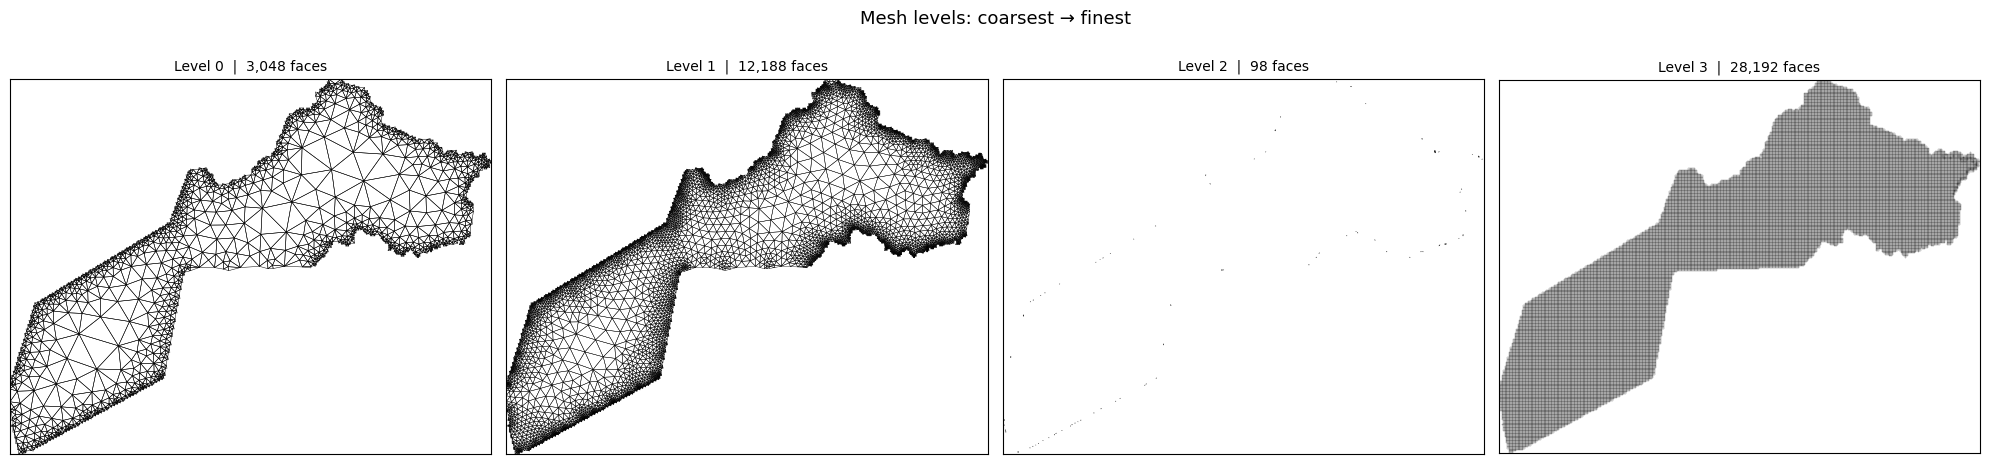

In [4]:
# Plot the 4 mesh levels (coarsest → finest)
from database.graph_creation import plot_faces

meshes = test_dataset[0].mesh.meshes
n = len(meshes)

fig, axs = plt.subplots(1, n, figsize=(n * 5, 5))
fig.suptitle("Mesh levels: coarsest → finest", fontsize=13)

for i, m in enumerate(meshes):
    ax = axs[i]
    lw = max(0.05, 0.35 - i * 0.07)  # thinner lines for finer meshes
    plot_faces(m, ax=ax, facecolor='none', edgecolor='black', linewidth=lw)
    ax.set_aspect('equal')
    ax.set_title(f"Level {i}  |  {m.face_x.shape[0]:,} faces", fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

In [5]:
#plot_multiscale_mesh_properties(test_dataset[0].mesh.meshes)

In [6]:
# Build and load model
# num_node_features must come from the TEMPORAL dataset (x includes previous_t steps)
from utils.dataset import to_temporal_dataset
temporal_test_dataset = to_temporal_dataset(test_dataset, rollout_steps=-1, **temporal_test_dataset_parameters)

num_node_features = temporal_test_dataset[0].x.size(-1)
num_edge_features = temporal_test_dataset[0].edge_attr.size(-1)
print(f"num_node_features: {num_node_features}, num_edge_features: {num_edge_features}")

model_parameters = dict(config.models)
model_type = model_parameters.pop("model_type")

if model_type == "MSGNN":
    model_parameters["num_scales"] = test_dataset[0].mesh.num_meshes

model = get_model(model_type)(
    num_node_features=num_node_features,
    num_edge_features=num_edge_features,
    previous_t=temporal_test_dataset_parameters["previous_t"],
    device=device,
    **model_parameters
).to(device)

plmodule_kwargs = {
    "model": model,
    "lr_info": config["lr_info"],
    "trainer_options": config.trainer_options,
    "temporal_test_dataset_parameters": temporal_test_dataset_parameters
}

plmodule = LightningTrainer.load_from_checkpoint(
    config.saved_model, map_location=device, **plmodule_kwargs
)
model = plmodule.model.to(device)
model.eval()
print("Model loaded from:", config.saved_model)

num_node_features: 8, num_edge_features: 1
Model loaded from: results/finetuned_dk15.h5


In [7]:
# Create PlotRollout — runs inference and builds comparison maps
plot_rollout = PlotRollout(
    model,
    test_dataset[0],
    scalers=scalers,
    **temporal_test_dataset_parameters
)
print("PlotRollout ready. Total time steps:", plot_rollout.real_rollout.shape[-1])

PlotRollout ready. Total time steps: 118


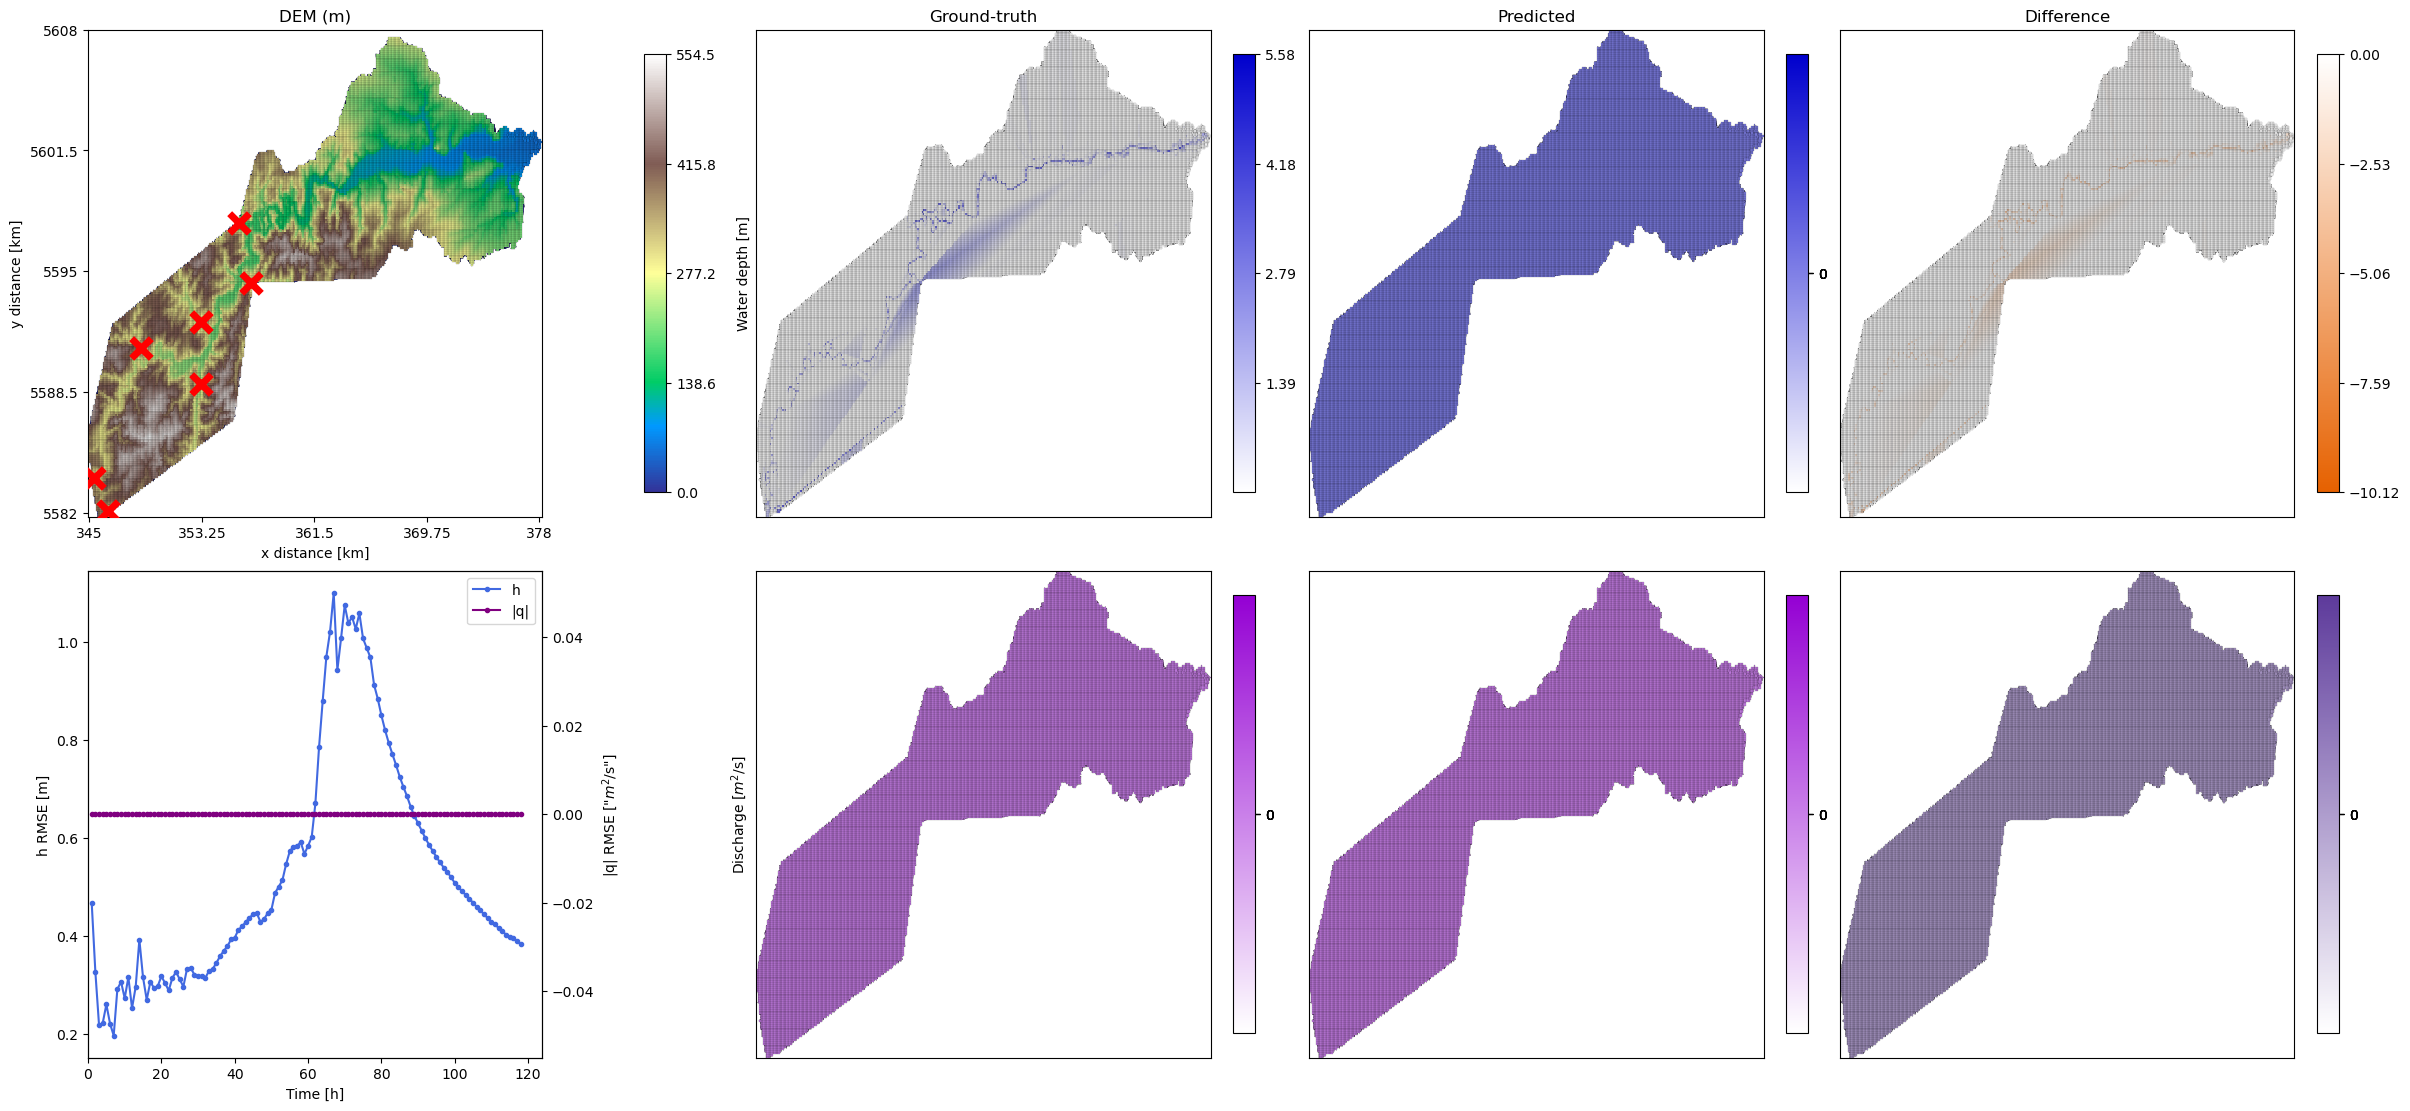

In [8]:
# Explore rollout at a given time step (use -1 for the last one)
# Shows DEM, ground truth, prediction, and difference for WD and V
fig = plot_rollout.explore_rollout(time_step=-1)
plt.show()

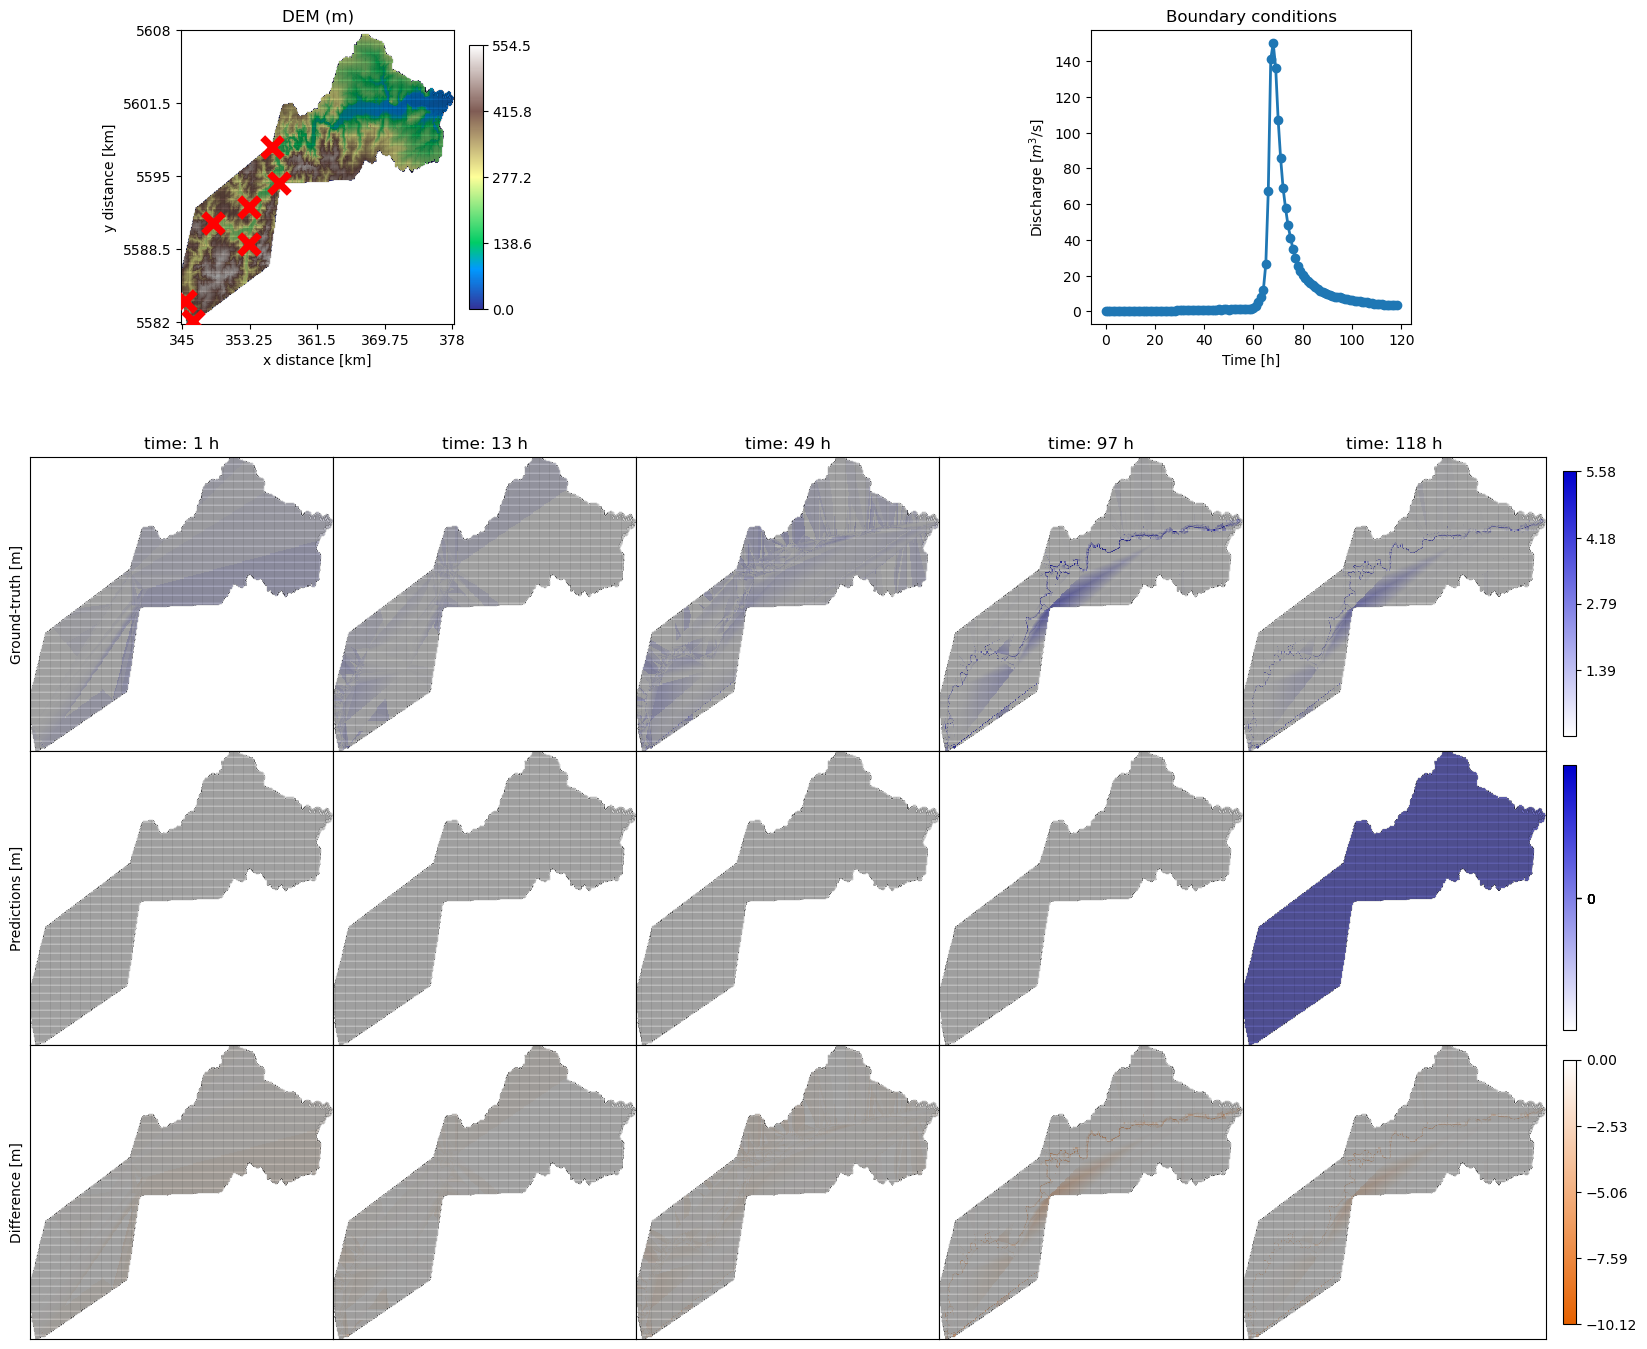

In [9]:
# Compare water depth at selected time steps (hours)
# 119 time steps @ 60 min = ~119 h total
plot_rollout.compare_h_rollout(plot_times=[0, 12, 48, 96])
plt.show()

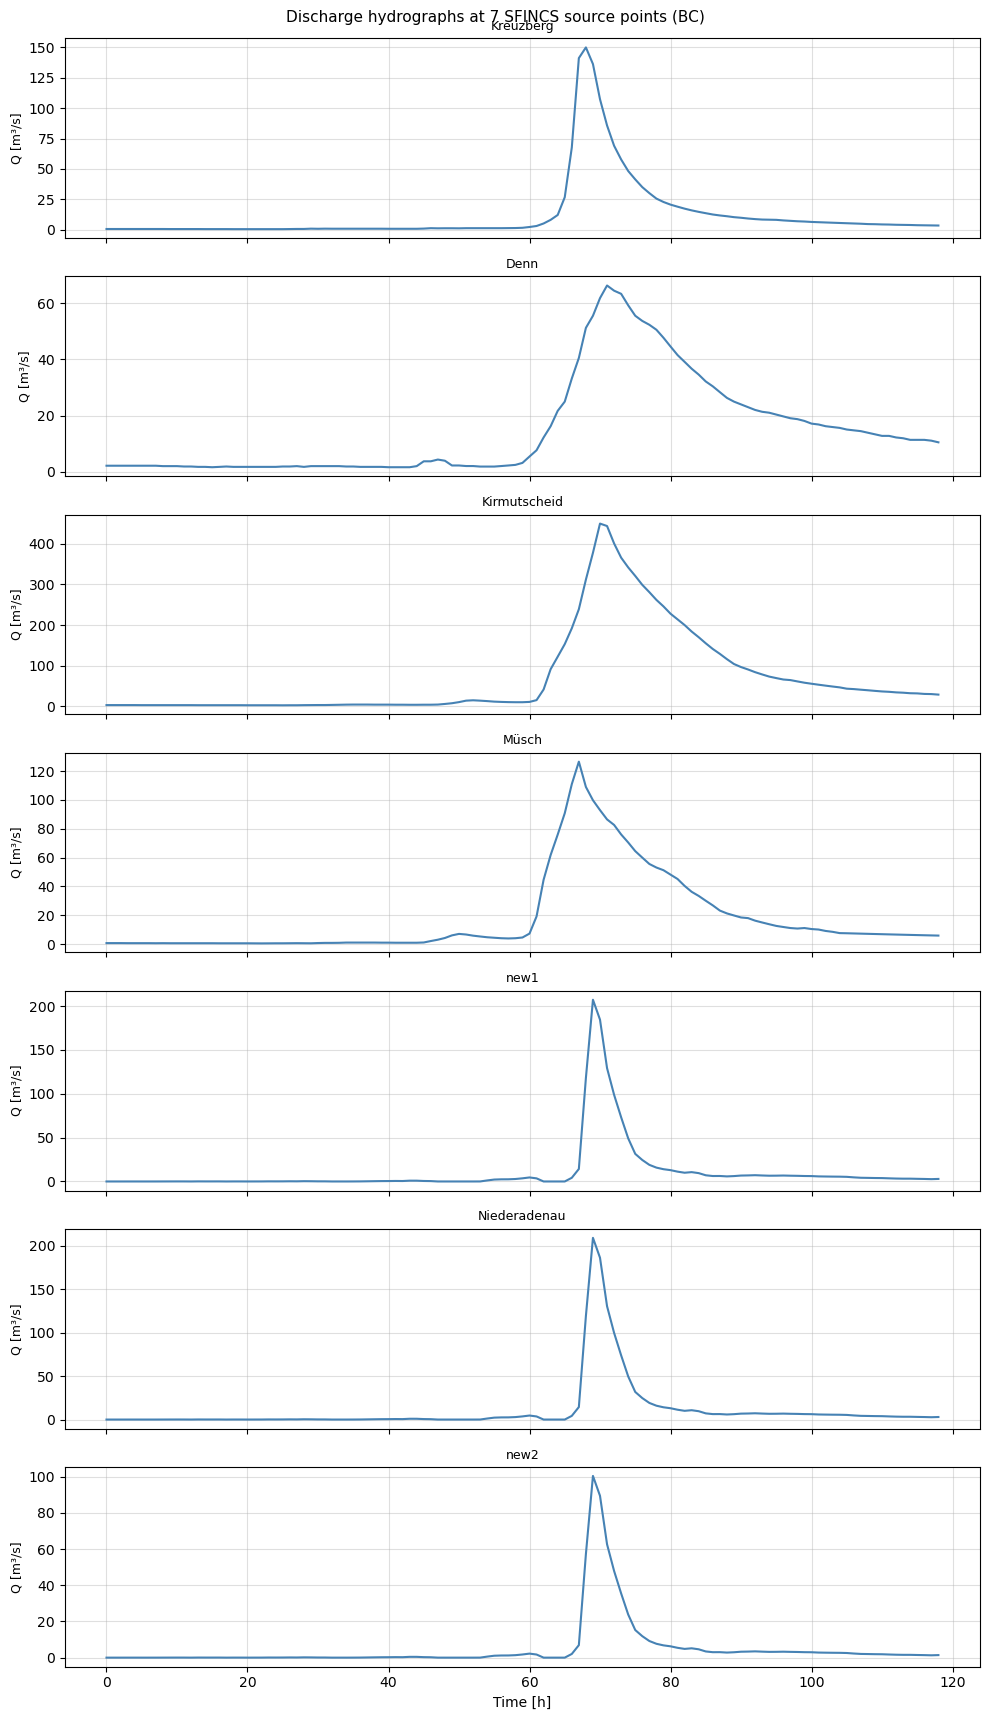

In [10]:
# All 7 source discharge hydrographs
# After create_model_dataset, BC is [n_bc, T] (channel already extracted by dataset.py)
import numpy as np

data = test_dataset[0]
src_names = ["Kreuzberg", "Denn", "Kirmutscheid", "Müsch", "new1", "Niederadenau", "new2"]
temporal_res = data.temporal_res  # minutes
bc = data.BC  # shape [n_bc, T]
n_bc = bc.shape[0]
t_hours = np.arange(bc.shape[1]) * temporal_res / 60.0

fig, axes = plt.subplots(n_bc, 1, figsize=(10, 2.5 * n_bc), sharex=True, facecolor='white')
for i, ax in enumerate(axes):
    q = bc[i].detach().cpu().numpy()
    ax.plot(t_hours, q, color='steelblue')
    ax.set_ylabel("Q [m³/s]", fontsize=9)
    ax.set_title(src_names[i] if i < len(src_names) else f"source {i}", fontsize=9)
    ax.grid(True, alpha=0.4)

axes[-1].set_xlabel("Time [h]")
fig.suptitle("Discharge hydrographs at 7 SFINCS source points (BC)", fontsize=11)
fig.tight_layout()
plt.show()

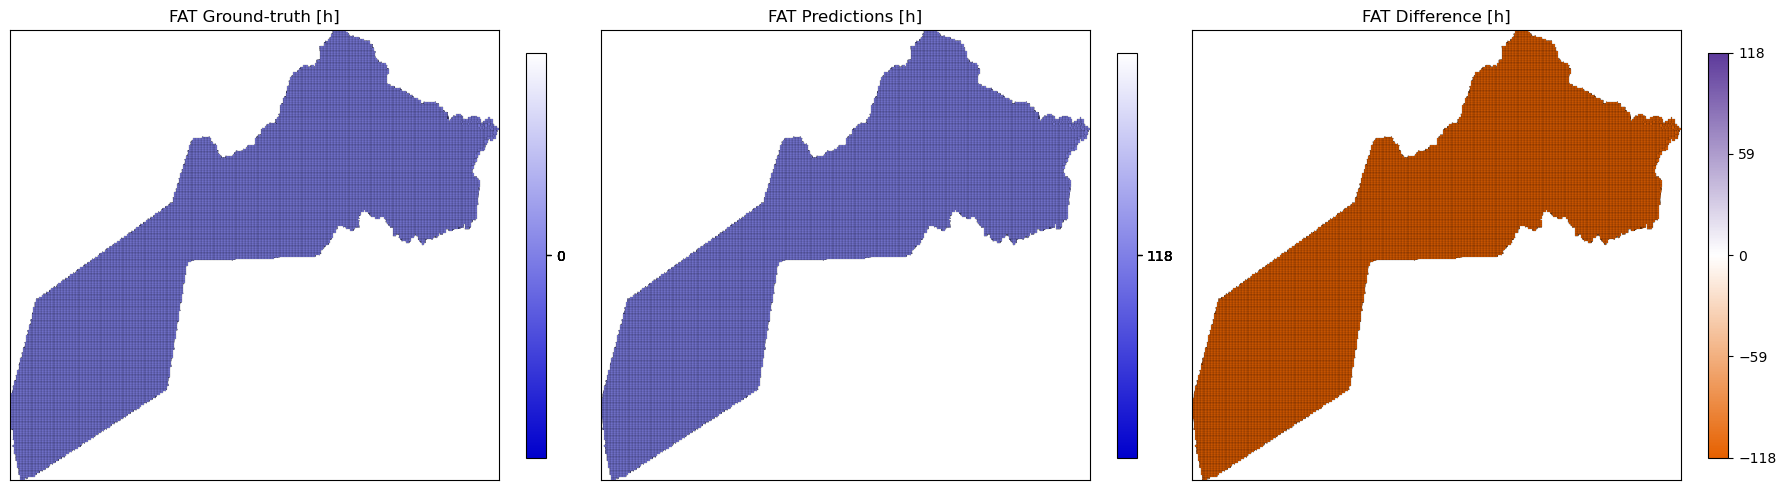

In [11]:
# Flood arrival time (FAT) comparison
plot_rollout.compare_FAT(water_threshold=0.05)
plt.show()

In [12]:
# Quantitative metrics
rollout_loss = plot_rollout._get_rollout_loss(type_loss="MAE")
loss_mean = rollout_loss.mean(0)  # average over simulations -> shape [n_vars] or scalar
print("rollout_loss shape:", rollout_loss.shape)
print(f"MAE WD:        {loss_mean[0].item():.4f} m" if loss_mean.dim() > 0 else f"MAE:  {loss_mean.item():.4f}")
if loss_mean.dim() > 0 and loss_mean.shape[0] > 1:
    print(f"MAE V:         {loss_mean[1:].mean().item():.4f} m^2/s")

csi_005 = plot_rollout._get_CSI(water_threshold=0.05).nanmean().item()
csi_03  = plot_rollout._get_CSI(water_threshold=0.30).nanmean().item()
print(f"CSI @ 0.05 m:  {csi_005:.4f}")
print(f"CSI @ 0.30 m:  {csi_03:.4f}")

rollout_loss shape: torch.Size([2])
MAE:  0.1470
CSI @ 0.05 m:  0.0000
CSI @ 0.30 m:  0.0000
